### Baixar bibliotecas e definir semente aleatória


In [ ]:
import wandb
import pandas as pd
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader , TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp , chi2_contingency
import yaml , random, matplotlib.pyplot as plt
import kagglehub , shutil , os

'''Ao configurar uma seed (semente) global nas bibliotecas, você padroniza o estado inicial
 de qualquer operação pseudo-aleatória muito importante para reprodutibilidade.'''
def set_seed(seed =42):
    random.seed(seed),
    np.random.seed(seed),
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed (42)

### Dicionário de Configuração geral

In [ ]:
config = {
    "data": {
        "raw_path": "data/raw/dataset.csv",
        "test_size": 0.2, # 20% reservados para testes
        "random_state": 42, # Semente para reprodutibilidade
        "target_col": "class", # Coluna alvo
        "missing_threshold": 0.5, # Eliminar colunas com >50% NaN   
        "imputation_strategy": "mean" # Preencher os valores NaN restantes com a média
    }
}

### Login no W&B

In [ ]:
import key

API_KEY = key.KEY 
wandb.login(key=API_KEY)

### Baixar base de dados

In [ ]:
# Download do dataset
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")
print(f"Downloaded to: {path}")

# Copia o dataset para a pasta destinada
destination = os.getcwd ()
shutil.copytree(path , os.path.join(destination , "data/"), dirs_exist_ok=True)

# Carregar aquivo principal de acidentes
df_raw = pd.read_csv("data/star_classification.csv", low_memory=False)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns) }...")

### Registrar dados brutos W&B

In [ ]:
wandb.init(project="star-classification", job_type="load_raw", name="load_raw")
artifact = wandb.Artifact("raw_data", type="dataset", description="star_classification raw dataset from Kaggle")
temp_path = "data/temp_raw.csv"
df_raw.to_csv(temp_path , index=False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_raw)
wandb.summary["columns"] = list(df_raw.columns)
wandb.finish()
print("Artefato raw_data salvo no W&B")

"""O procedimento load_raw consiste em registrar os dados brutos como um artefato versionado
 no Weights & Biases imediatamente após a ingestão, garantindo a rastreabilidade"""

### Limpando Dados

In [90]:
df_raw = pd.read_csv("data/star_classification.csv", sep=",")

# Dataset principal não possui dados faltantes
df_raw.info() 

#Criando um arquivo para limpeza
temp_path = "data/temp_clean.csv"
df_raw.to_csv(temp_path, index = False)
df_clean = pd.read_csv("data/temp_clean.csv", sep=",")

# Eliminando colunas irrelevantes 
df_clean.drop(['run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID', 'plate', 'MJD'], axis=1, inplace=True)

# u, g e z têm valores de -9999 que são considerados nulos, devemos remover
#df_clean.describe()
#df_clean[df_clean['u'] <= 0]['u']
#df_clean[df_clean['g'] <= 0]['g']
#df_clean[df_clean['z'] <= 0]['z']

# Removendo o valor de index 79543 que possui dados nulos
df_clean.drop(index=79543, inplace=True)

# Salvando alterações no arquivo temporário
df_clean.to_csv('data/temp_clean.csv', index=False)
df_clean.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

,obj_ID,alpha,delta,u,g,r,i,z,redshift
count,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.237665e+18,177.628653,24.135552,22.080679,20.631583,19.645777,19.084865,18.768988,0.576667
std,8.438450e+12,96.502612,19.644608,2.251068,2.037384,1.854763,1.757900,1.765982,0.730709
min,1.237646e+18,0.005528,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971
25%,1.237659e+18,127.517698,5.147477,20.352410,18.965240,18.135795,17.732280,17.460830,0.054522
50%,1.237663e+18,180.900527,23.646462,22.179140,21.099930,20.125310,19.405150,19.004600,0.424176
75%,1.237668e+18,233.895005,39.901582,23.687480,22.123775,21.044790,20.396510,19.921120,0.704172
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


### Visualização de dados e análise exploratória de dados


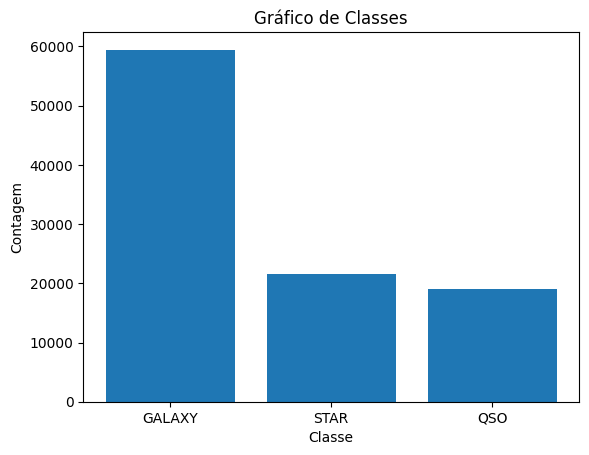

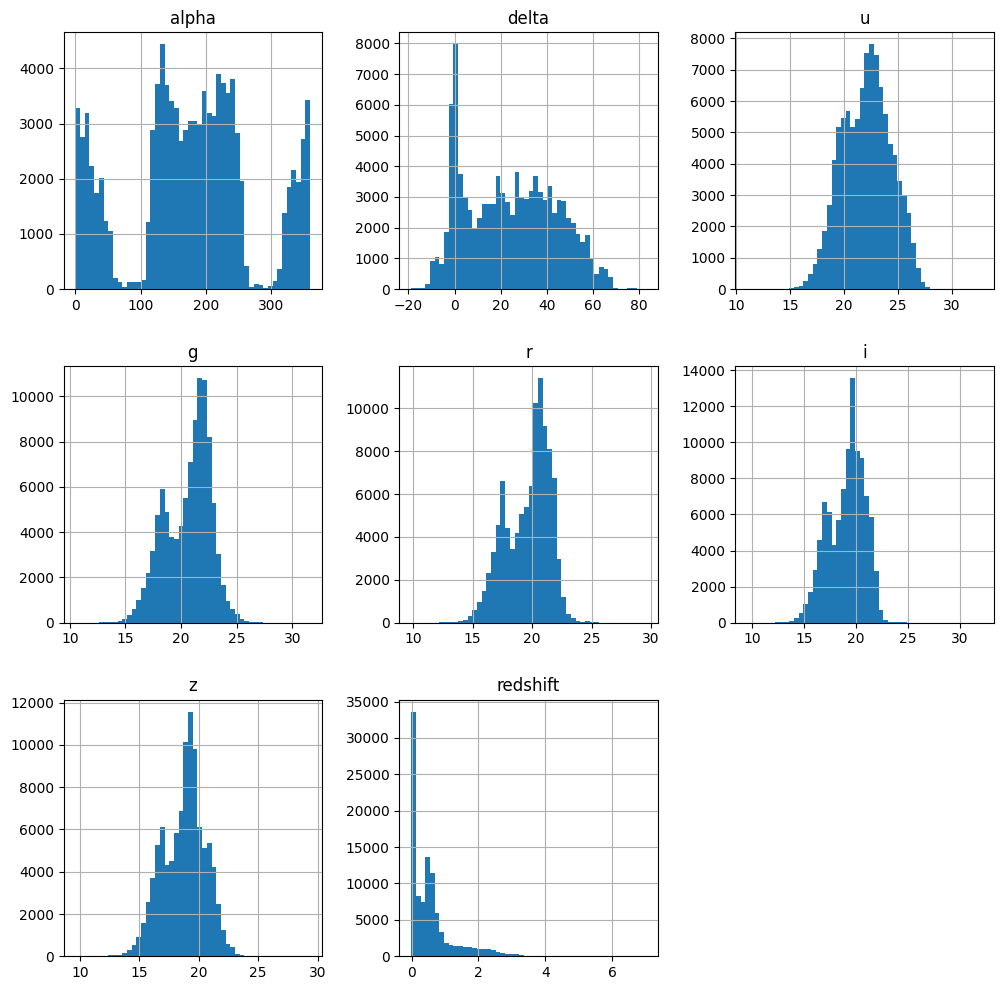

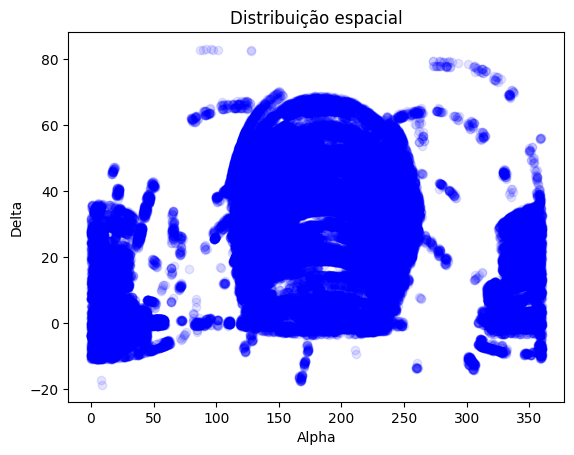

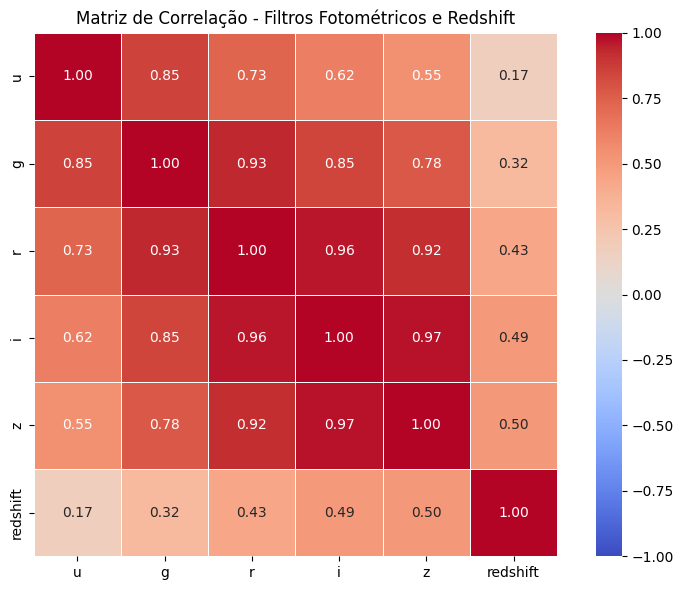

In [91]:
#Gráfico de Barras
cont = df_clean['class'].value_counts()
plt.bar(cont.index, cont.values)
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Gráfico de Classes')
plt.show()

# Histograma das distribuição do todo em cada caracteristica
df_clean.hist(column=['alpha', 'delta', 'u', 'g', 'r', 'i', 'z','redshift'], bins=50, figsize=(12,12))
plt.show()

# Gráfico de Dispersão da distribuição dos corpos de acordo com as coordenadas na esfera celeste
plt.scatter(df_clean['alpha'], df_clean['delta'], color="blue", alpha=0.1)
plt.xlabel('Alpha')
plt.ylabel('Delta')
plt.title('Distribuição espacial')
plt.show()

# Mapa de calor 
cols = ['u', 'g', 'r', 'i', 'z', 'redshift'] # Dados relevantes com caracteristicas físicas
corr_matrix = df_clean[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,      # Mostra os valores de 'r' em cada célula
    fmt='.2f', 
    cmap='coolwarm', # Azul para negativo, vermelho para positivo
    vmin=-1, vmax=1, # Escala padrão da correlação de Pearson
    linewidths=0.5, 
    square=True
)
plt.title('Matriz de Correlação - Filtros Fotométricos e Redshift')
plt.tight_layout()
plt.show()



### Registrar dados limpos W&B


In [ ]:
wandb.init(project ="star-classification",job_type ="clean_data",name ="clean_data")
artifact = wandb.Artifact("clean_data",type = "dataset", description ="star_classification after deduplication and imputation")
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_clean)
wandb.summary["dropped_columns"] = df_clean.shape[1]
wandb.finish()